**Experiment 1**

In [6]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
df = pd.read_csv(r"D:\mlop 462\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Streami

In [8]:
print("\nDataset Information:")
df.info()

print("\nColumn Names:")
print(df.columns.tolist())

print("\nStatistical Summary:")
print(df.describe(include="all"))


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null

In [9]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
df.replace(" ", np.nan, inplace=True)

print("\nMissing Values After Replacement:")
print(df.isnull().sum())


Missing Values After Replacement:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (7043, 21)


In [12]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df["TotalCharges"].dtype)

float64


In [13]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [14]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 customerID
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

 gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

 Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

 Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

 PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

 MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

 InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

 OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

 OnlineBackup
OnlineBackup
No                     3088
Yes                

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15912\2799631412.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [15]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [16]:
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

In [17]:
df = pd.get_dummies(
    df,
    drop_first=True
)

print("Dataset after encoding:")
print(df.head())

Dataset after encoding:
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...      

In [18]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Experiment 2**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (5634, 30)
X_test_scaled shape: (1409, 30)


In [24]:
scaler.fit_transform(X_train)

array([[-0.44177295,  0.10237124, -0.52197565, ..., -0.52380561,
         1.40690298, -0.54384572],
       [-0.44177295, -0.71174346,  0.33747781, ..., -0.52380561,
        -0.71078107,  1.83875676],
       [-0.44177295, -0.79315493, -0.80901319, ..., -0.52380561,
        -0.71078107,  1.83875676],
       ...,
       [ 2.2636062 , -0.30468611,  1.25666162, ..., -0.52380561,
        -0.71078107,  1.83875676],
       [-0.44177295, -0.34539184, -1.47766135, ...,  1.90910518,
        -0.71078107, -0.54384572],
       [-0.44177295, -1.07809507, -1.46936546, ..., -0.52380561,
        -0.71078107,  1.83875676]], shape=(5634, 30))

In [25]:
scaler.transform(X_test)

array([[-0.44177295,  1.60848343,  1.62997635, ...,  1.90910518,
        -0.71078107, -0.54384572],
       [ 2.2636062 , -0.9966836 ,  1.16872526, ...,  1.90910518,
        -0.71078107, -0.54384572],
       [-0.44177295,  0.34660565,  0.44532428, ...,  1.90910518,
        -0.71078107, -0.54384572],
       ...,
       [-0.44177295, -1.11880081, -1.46936546, ..., -0.52380561,
        -0.71078107, -0.54384572],
       [-0.44177295,  0.95719167, -1.50088982, ..., -0.52380561,
        -0.71078107, -0.54384572],
       [-0.44177295,  1.60848343,  0.18317439, ..., -0.52380561,
        -0.71078107, -0.54384572]], shape=(1409, 30))

In [26]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression predictions:")
print(lr_pred[:10])

Logistic Regression predictions:
[0 1 0 0 0 1 0 0 0 0]


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Logistic Regression Results")
print("---------------------------")

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1 Score:",
      f1_score(y_test, lr_pred))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          lr_model.predict_proba(X_test_scaled)[:, 1]
      ))

Logistic Regression Results
---------------------------
Accuracy: 0.8069552874378992
Precision: 0.6583850931677019
Recall: 0.5668449197860963
F1 Score: 0.6091954022988506
ROC-AUC: 0.8415846443979436


In [28]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(
    X_train_scaled,
    y_train
)

dt_pred = dt_model.predict(X_test_scaled)

print("Decision Tree training completed!")

Decision Tree training completed!


In [29]:
print("Decision Tree Results")
print("---------------------")

print("Accuracy:",
      accuracy_score(y_test, dt_pred))

print("Precision:",
      precision_score(y_test, dt_pred))

print("Recall:",
      recall_score(y_test, dt_pred))

print("F1 Score:",
      f1_score(y_test, dt_pred))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          dt_model.predict_proba(X_test_scaled)[:, 1]
      ))

Decision Tree Results
---------------------
Accuracy: 0.794180269694819
Precision: 0.6296296296296297
Recall: 0.5454545454545454
F1 Score: 0.5845272206303725
ROC-AUC: 0.8283577462605594


In [30]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(
    X_train_scaled,
    y_train
)

rf_pred = rf_model.predict(X_test_scaled)

print("Random Forest training completed!")

Random Forest training completed!


In [31]:
print("Random Forest Results")
print("---------------------")

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          rf_model.predict_proba(X_test_scaled)[:, 1]
      ))

Random Forest Results
---------------------
Accuracy: 0.7757274662881476
Precision: 0.5674418604651162
Recall: 0.6524064171122995
F1 Score: 0.6069651741293532
ROC-AUC: 0.8276111498617892


In [32]:
def evaluate_model(name, model, X_test, y_test):

    prediction = model.predict(X_test)

    probability = model.predict_proba(X_test)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(
            y_test, prediction
        ),
        "Precision": precision_score(
            y_test, prediction
        ),
        "Recall": recall_score(
            y_test, prediction
        ),
        "F1 Score": f1_score(
            y_test, prediction
        ),
        "ROC-AUC": roc_auc_score(
            y_test, probability
        )
    }

In [33]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        lr_model,
        X_test_scaled,
        y_test
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        dt_model,
        X_test_scaled,
        y_test
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        rf_model,
        X_test_scaled,
        y_test
    )
)

In [34]:
results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.806955   0.658385  0.566845  0.609195  0.841585
1        Decision Tree  0.794180   0.629630  0.545455  0.584527  0.828358
2        Random Forest  0.775727   0.567442  0.652406  0.606965  0.827611


In [35]:
print("Random Forest Classification Report")
print("-------------------------------------")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Random Forest Classification Report
-------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.65      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [36]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[849 186]
 [130 244]]


In [37]:
incorrect = y_test != rf_pred

print(
    "Number of incorrect predictions:",
    incorrect.sum()
)

Number of incorrect predictions: 316


In [38]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_pred
})

print(comparison[comparison["Actual"] != comparison["Predicted"]].head(10))

      Actual  Predicted
2280       0          1
5748       0          1
2136       0          1
1838       0          1
2488       1          0
2519       0          1
5400       0          1
523        1          0
5086       1          0
7011       1          0


In [39]:
import joblib
import os

In [40]:
os.makedirs("models", exist_ok=True)

In [41]:
joblib.dump(
    rf_model,
    "models/random_forest_churn.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [42]:
joblib.dump(
    scaler,
    "models/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [43]:
loaded_model = joblib.load(
    "models/random_forest_churn.pkl"
)

loaded_scaler = joblib.load(
    "models/scaler.pkl"
)

print("Model and scaler loaded successfully!")

Model and scaler loaded successfully!


In [44]:
sample = X_test.iloc[[0]]

sample_scaled = loaded_scaler.transform(sample)

prediction = loaded_model.predict(sample_scaled)

probability = loaded_model.predict_proba(
    sample_scaled
)[0][1]

print("Predicted Class:", prediction[0])
print("Churn Probability:", probability)

Predicted Class: 0
Churn Probability: 0.0


In [45]:
if prediction[0] == 1:
    print("Prediction: Customer will churn")
else:
    print("Prediction: Customer will not churn")

print(
    f"Churn probability: {probability:.2%}"
)

Prediction: Customer will not churn
Churn probability: 0.00%


In [46]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                           Feature  Importance
3                     TotalCharges    0.176207
1                           tenure    0.164924
2                   MonthlyCharges    0.151313
25               Contract_Two year    0.059640
10     InternetService_Fiber optic    0.041576
28  PaymentMethod_Electronic check    0.036921
24               Contract_One year    0.030307
13              OnlineSecurity_Yes    0.028689
4                      gender_Male    0.026024
26            PaperlessBilling_Yes    0.024110


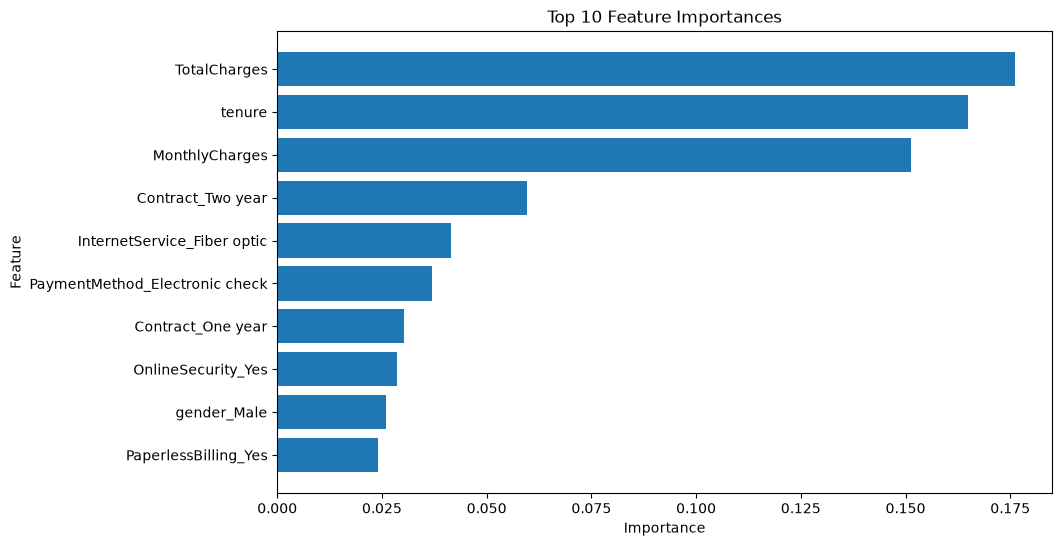

In [47]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.gca().invert_yaxis()

plt.show()